# PHẦN 1: GIỚI THIỆU DỮ LIỆU

## 1.1. Lý do chọn đề tài
Hiện nay, nhu cầu tìm kiếm phòng trọ của sinh viên tại Thành phố Hồ Chí Minh rất cao, nhưng thông tin thị trường còn phân tán, khó so sánh. Việc thu thập, làm sạch và phân tích dữ liệu giúp hiểu rõ hơn về giá thuê, vị trí, diện tích và các yếu tố ảnh hưởng, đồng thời hỗ trợ sinh viên tìm phòng phù hợp và chủ trọ định giá hợp lý.

## 1.2. Nguồn dữ liệu
* Website thu thập: https://phongtro123.com/
* Thời gian thu thập: Năm 2025
* Số lượng bản ghi: Khoảng 7.000 tin đăng
* Phạm vi địa lý: Các quận trung tâm và ngoại thành TP.HCM (Quận 1, Gò Vấp, Bình Thạnh, Thủ Đức, Quận 9, Quận 12, v.v.)

## 1.3. Mục tiêu nghiên cứu
* Phân tích đặc điểm thị trường cho thuê phòng trọ tại TP.HCM.
* Khám phá mối quan hệ giữa giá thuê, diện tích và vị trí địa lý.
* Xây dựng mô hình phân cụm và dự đoán giá phòng trọ dựa trên các đặc tính cơ bản.

## 1.4. Câu hỏi nghiên cứu (Tổng hợp)
1. Thị trường phòng trọ TP.HCM được phân khúc như thế nào dựa trên giá cả, diện tích và vị trí địa lý?
  	 Sử dụng: Phân cụm K-Means + DBSCAN
2. Yếu tố nào ảnh hưởng mạnh nhất đến giá thuê phòng trọ: diện tích hay vị trí quận?
  	 Sử dụng: Correlation analysis + Regression
3. Có thể dự đoán chính xác phân khúc giá của phòng trọ dựa trên các đặc tính cơ bản không?
   	Sử dụng: Classification models (Random Forest, XGBoost)
4. Sự khác biệt về giá thuê và đặc điểm phòng trọ giữa các quận trung tâm và ngoại thành như thế nào?
    Sử dụng: Comparative analysis + Visualization
5. Phân khúc phòng trọ nào mang lại giá trị tốt nhất cho người thuê về tỷ lệ giá/diện tích/vị trí?
    Sử dụng: Value analysis + Cluster interpretation

## 1.5. Cấu trúc tập dữ liệu

| Tên trường      | Mô tả                      |
| --------------- | -------------------------- |
| `url`           | Liên kết gốc của tin đăng  |
| `title`         | Tiêu đề bài viết           |
| `price_raw`     | Giá thuê thô (chuỗi ký tự) |
| `area_raw`      | Diện tích thô              |
| `address`       | Địa chỉ chi tiết           |
| `post_code`     | Mã bài đăng                |
| `description`   | Mô tả nội dung             |
| `contact_phone` | Số điện thoại liên hệ      |
| `images`        | Đường dẫn hình ảnh         |


# PHẦN 2: PHÂN TÍCH MÔ TẢ

## 2.1. Nhập thư viện

In [1]:
# pip install aiohttp async-timeout tqdm pandas beautifulsoup4 lxml requests
!pip install streamlit -q

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import streamlit as st

from urllib.parse import urlparse, unquote

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)


## 2.2. Đọc dữ liệu

In [3]:
df = pd.read_csv("/kaggle/input/crawl-house-hcm-vietnam/results_hcm.csv")
df.head(10)

,url,title,date,price_raw,area_raw,address,post_code,description,contact_phone,images
0,https://phongtro123.com/tinh-thanh/ho-chi-minh,"Cho Thuê Phòng Trọ Hồ Chí Minh, Giá Rẻ, Tiện N...",Hôm nay,13 K,25 m2,Tin đã lưu Đăng ký Đăng nhập Đăng tin Phongtro...,NaN,"Chủ sở hữu Nhà Trọ Ngõ Sen chia sẻ rằng: ""Trướ...",974188183.0,['https://pt123.cdn.static123.com/images/thumb...
1,https://phongtro123.com/tinh-thanh/ho-chi-minh...,"Cho Thuê Phòng Trọ Quận 1, Giá Rẻ, Tiện Nghi, ...",Hôm nay,3.5 triệu/tháng,25 m2,Tin đã lưu Đăng ký Đăng nhập Đăng tin Phongtro...,NaN,"Bên cạnh đó, hệ thống giao thông quận 1 rất hi...",917686101.0,['https://pt123.cdn.static123.com/images/thumb...
2,https://phongtro123.com/tinh-thanh/ho-chi-minh...,"Cho Thuê Phòng Trọ Quận 12, Giá Rẻ, Tiện Nghi,...",Hôm nay,3.5 triệu/tháng,35 m2,Tin đã lưu Đăng ký Đăng nhập Đăng tin Phongtro...,NaN,Theo dữ liệu cập nhật chính xác từ https://pho...,914579786.0,['https://pt123.cdn.static123.com/images/thumb...
3,https://phongtro123.com/tinh-thanh/ho-chi-minh...,"Cho Thuê Phòng Trọ Thủ Đức, Giá Rẻ, Tiện Nghi,...",Hôm nay,1.2 triệu/tháng,20 m2,Tin đã lưu Đăng ký Đăng nhập Đăng tin Phongtro...,NaN,Chị Trần Thị Ngọc Mai - chủ phòng trọ cho thuê...,936456678.0,['https://pt123.cdn.static123.com/images/thumb...
4,https://phongtro123.com/tinh-thanh/ho-chi-minh...,"Cho Thuê Phòng Trọ Quận 9, Giá Rẻ, Tiện Nghi, ...",Hôm nay,13 K,30 m2,Tin đã lưu Đăng ký Đăng nhập Đăng tin Phongtro...,NaN,Quận 9 nằm ở phía Đông của thành phố Hồ Chí Mi...,917686101.0,['https://pt123.cdn.static123.com/images/thumb...
5,https://phongtro123.com/tinh-thanh/ho-chi-minh...,"Cho Thuê Phòng Trọ Gò Vấp, Giá Rẻ, Tiện Nghi, ...",Hôm nay,13 K,20 m2,Tin đã lưu Đăng ký Đăng nhập Đăng tin Phongtro...,NaN,Hiện tại có hàng tá website thương mại điện tử...,974188183.0,['https://pt123.cdn.static123.com/images/thumb...
6,https://phongtro123.com/tinh-thanh/ho-chi-minh...,"Cho Thuê Phòng Trọ Bình Thạnh, Giá Rẻ, Tiện Ng...",Hôm nay,3.5 triệu/tháng,15 m2,Tin đã lưu Đăng ký Đăng nhập Đăng tin Phongtro...,NaN,Theo số liệu thống kê từ https://phongtro123.c...,909814679.0,['https://pt123.cdn.static123.com/images/thumb...
7,https://phongtro123.com/tinh-thanh/ho-chi-minh...,"Cho Thuê Phòng Trọ Tân Bình, Giá Rẻ, Tiện Nghi...",Hôm nay,3.5 triệu/tháng,25 m2,Tin đã lưu Đăng ký Đăng nhập Đăng tin Phongtro...,NaN,"Anh Ba - chủ một dãy trọ tại quận Tân Bình , T...",913265940.0,['https://pt123.cdn.static123.com/images/thumb...
8,https://phongtro123.com/tinh-thanh/ho-chi-minh...,"Cho Thuê Phòng Trọ Tân Phú, Giá Rẻ, Tiện Nghi,...",Hôm nay,1.9 triệu/tháng,10 m2,Tin đã lưu Đăng ký Đăng nhập Đăng tin Phongtro...,NaN,"Trong thời đại công nghệ ngày càng phát triển,...",938864405.0,['https://pt123.cdn.static123.com/images/thumb...
9,https://phongtro123.com/tinh-thanh/ho-chi-minh...,"Cho Thuê Phòng Trọ Phú Nhuận, Giá Rẻ, Tiện Ngh...",Hôm nay,5 triệu/tháng,25 m2,Tin đã lưu Đăng ký Đăng nhập Đăng tin Phongtro...,NaN,"Với hơn 10 năm hình thành và phát triển, Phong...",928161541.0,['https://pt123.cdn.static123.com/images/thumb...


**Ý nghĩa của mỗi dòng:** thông tin về giá nhà ở một khu vực ở Hồ Chí Minh.

In [4]:
print(f" Kích thước dữ liệu: {df.shape}")
print(f" Các cột: {list(df.columns)}")
print(f" Số lượng bản ghi: {len(df):,}")

 Kích thước dữ liệu: (7561, 10)
 Các cột: ['url', 'title', 'date', 'price_raw', 'area_raw', 'address', 'post_code', 'description', 'contact_phone', 'images']
 Số lượng bản ghi: 7,561


**124 dòng đầu tiên là load Category Page – không phải bài đăng thật**

In [5]:
df.head(126)

,url,title,date,price_raw,area_raw,address,post_code,description,contact_phone,images
0,https://phongtro123.com/tinh-thanh/ho-chi-minh,"Cho Thuê Phòng Trọ Hồ Chí Minh, Giá Rẻ, Tiện N...",Hôm nay,13 K,25 m2,Tin đã lưu Đăng ký Đăng nhập Đăng tin Phongtro...,NaN,"Chủ sở hữu Nhà Trọ Ngõ Sen chia sẻ rằng: ""Trướ...",974188183.0,['https://pt123.cdn.static123.com/images/thumb...
1,https://phongtro123.com/tinh-thanh/ho-chi-minh...,"Cho Thuê Phòng Trọ Quận 1, Giá Rẻ, Tiện Nghi, ...",Hôm nay,3.5 triệu/tháng,25 m2,Tin đã lưu Đăng ký Đăng nhập Đăng tin Phongtro...,NaN,"Bên cạnh đó, hệ thống giao thông quận 1 rất hi...",917686101.0,['https://pt123.cdn.static123.com/images/thumb...
2,https://phongtro123.com/tinh-thanh/ho-chi-minh...,"Cho Thuê Phòng Trọ Quận 12, Giá Rẻ, Tiện Nghi,...",Hôm nay,3.5 triệu/tháng,35 m2,Tin đã lưu Đăng ký Đăng nhập Đăng tin Phongtro...,NaN,Theo dữ liệu cập nhật chính xác từ https://pho...,914579786.0,['https://pt123.cdn.static123.com/images/thumb...
3,https://phongtro123.com/tinh-thanh/ho-chi-minh...,"Cho Thuê Phòng Trọ Thủ Đức, Giá Rẻ, Tiện Nghi,...",Hôm nay,1.2 triệu/tháng,20 m2,Tin đã lưu Đăng ký Đăng nhập Đăng tin Phongtro...,NaN,Chị Trần Thị Ngọc Mai - chủ phòng trọ cho thuê...,936456678.0,['https://pt123.cdn.static123.com/images/thumb...
4,https://phongtro123.com/tinh-thanh/ho-chi-minh...,"Cho Thuê Phòng Trọ Quận 9, Giá Rẻ, Tiện Nghi, ...",Hôm nay,13 K,30 m2,Tin đã lưu Đăng ký Đăng nhập Đăng tin Phongtro...,NaN,Quận 9 nằm ở phía Đông của thành phố Hồ Chí Mi...,917686101.0,['https://pt123.cdn.static123.com/images/thumb...
...,...,...,...,...,...,...,...,...,...,...
121,https://phongtro123.com/cho-thue-can-ho-chung-...,"Cho Thuê Căn Hộ Mini + Chung Cư Mini TPHCM, Mớ...",Hôm nay,8.5 triệu/tháng,30 m2,Tin đã lưu Đăng ký Đăng nhập Đăng tin Phongtro...,NaN,"Anh Nguyễn Hữu Tình, chủ sở hữu căn hộ mini qu...",909316890.0,['https://pt123.cdn.static123.com/images/thumb...
122,https://phongtro123.com/cho-thue-can-ho-dich-v...,"Cho Thuê Căn Hộ Dịch Vụ Hồ Chí Minh, Giá Rẻ, M...",Hôm nay,7 triệu/tháng,40 m2,Tin đã lưu Đăng ký Đăng nhập Đăng tin Phongtro...,NaN,Anh Nguyễn Minh Kiên chủ căn hộ dịch vụ Studio...,909002690.0,['https://pt123.cdn.static123.com/images/thumb...
123,https://phongtro123.com/con-duy-nhat-1-phong-c...,Còn duy nhất 1 phòng cho thuê. Đường Hoàng Văn...,Cập nhật: 1 ngày trước,3.5 triệu/tháng,26 m2,"Đường Hoàng Văn Thụ, Phường 2, Quận Tân Bình, ...",695741.0,"Khu dân cư yên tĩnh, an ninh, ngay vòng xoay L...",832195108.0,['https://pt123.cdn.static123.com/images/thumb...
124,https://phongtro123.com/ki-tuc-xa-tu-nha-gia-r...,KÍ TÚC XÁ TƯ NHÂ GIÁ RẺ QUẬN 2 THỦ ĐỨC TP HỒ C...,Cập nhật: 2 ngày trước,1 triệu/tháng,21 m2,"82 Đường số 17, Phường An Phú, Quận 2, Hồ Chí ...",695476.0,KÍ TÚC XÁ TƯ NHÂN QUẬN 2 1.000.000 - 1.200.000...,966209510.0,['https://pt123.cdn.static123.com/images/thumb...


In [6]:
# Bỏ 124 dòng đầu tiên
df = df.iloc[124:].reset_index(drop=True)

**Số dòng, số cột:**

In [7]:
num_rows, num_cols = df.shape
print("Num rows: ", num_rows)
print("Num cols: ", num_cols)

Num rows:  7437
Num cols:  10


In [8]:
# lay danh sach ten cac cot
list(df.columns)

['url',
 'title',
 'date',
 'price_raw',
 'area_raw',
 'address',
 'post_code',
 'description',
 'contact_phone',
 'images']

In [9]:
df.info() # thong ke du lieu

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7437 entries, 0 to 7436
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   url            7437 non-null   object 
 1   title          7436 non-null   object 
 2   date           7436 non-null   object 
 3   price_raw      7436 non-null   object 
 4   area_raw       6673 non-null   object 
 5   address        7436 non-null   object 
 6   post_code      7436 non-null   float64
 7   description    7436 non-null   object 
 8   contact_phone  7436 non-null   float64
 9   images         7436 non-null   object 
dtypes: float64(2), object(8)
memory usage: 581.1+ KB


## 2.3. Thống kê cơ bản

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
post_code,7436.0,2.960505e+05,4.062083e+04,392.0,2.872368e+05,290004.0,2.962182e+05,6.954760e+05
contact_phone,7436.0,6.014163e+08,1.727830e+09,1600000.0,1.909392e+08,703362283.0,9.172507e+08,8.493400e+10


# PHẦN 3: PHÂN TÍCH DỮ LIỆU (TIỀN XỬ LÝ DỮ LIỆU)

In [11]:
# Tạo bản sao để tránh thay đổi dữ liệu gốc
df = df.copy()

## 3.1. Làm sạch dữ liệu (Data Cleaning): Xử lý dữ liệu bị thiếu, nhiễu, không chính xác hoặc trùng lặp để cải thiện tính nhất quán và độ tin cậy.

###  **Giá trị trùng lặp**

In [12]:
# Xử lý trùng lặp
duplicate_rows_data = df[df.duplicated()]
print("number of duplicate rows: ", duplicate_rows_data.shape)

number of duplicate rows:  (0, 10)


### **Tính độc nhất**

In [13]:
# Kiểm tra các giá trị duy nhất
for col in df.columns:
    unique_count = df[col].nunique()
    print(f"{col}: {unique_count} giá trị duy nhất")

url: 7437 giá trị duy nhất
title: 7431 giá trị duy nhất
date: 30 giá trị duy nhất
price_raw: 280 giá trị duy nhất
area_raw: 234 giá trị duy nhất
address: 7436 giá trị duy nhất
post_code: 7436 giá trị duy nhất
description: 7380 giá trị duy nhất
contact_phone: 5704 giá trị duy nhất
images: 7191 giá trị duy nhất


### **Kiểm tra dữ liệu bị thiếu:**

In [14]:
# Xử lý giá trị thiếu
missing_data = df.isnull().sum()                          # Kiểm tra giá trị null
missing_percent = (df.isnull().sum() / len(df)) * 100     # Tỉ lệ giá trị bị thiếu ở mỗi cột:
missing_info = pd.DataFrame({
    'Số lượng thiếu': missing_data,
    'Tỷ lệ thiếu (%)': missing_percent
})
print(missing_info)

               Số lượng thiếu  Tỷ lệ thiếu (%)
url                         0         0.000000
title                       1         0.013446
date                        1         0.013446
price_raw                   1         0.013446
area_raw                  764        10.272960
address                     1         0.013446
post_code                   1         0.013446
description                 1         0.013446
contact_phone               1         0.013446
images                      1         0.013446


In [15]:
# Xử lý các giá trị đặc biệt
df.replace([np.inf, -np.inf], np.nan, inplace=True)

## 3.2. Chuyển đổi dữ liệu (Data Transformation): Chuẩn hóa, tổng quát hóa hoặc chuyển đổi dữ liệu sang một định dạng phù hợp hơn. Ví dụ, chuyển đổi các giá trị văn bản thành các số hoặc chuẩn hóa các giá trị trong một phạm vi nhất định

### Chuẩn hóa giá thuê

In [16]:
def parse_price_to_million(x):
    if pd.isna(x):
        return np.nan
    s = str(x).lower().replace(' ', '')
    
    # 1. Xử lý triệu/tháng trước
    if 'triệu' in s:
        m = re.search(r'([\d\.,]+)', s)
        if m:
            # Thay dấu phân cách hàng nghìn trước khi chuyển đổi
            num = m.group(1).replace(',', '.')
            return float(num)
    
    # 2. Xử lý k/nghìn/ngàn -> chia 1000 để ra triệu
    if 'k' in s or 'nghìn' in s or 'ngàn' in s:
        m = re.search(r'([\d\.,]+)', s)
        if m:
            num_str = m.group(1).replace(',', '.')
            val = float(num_str)
            return val / 1000
            
    
    # 3. Xử lý chỉ có số
    m = re.search(r'([\d\.,]+)', s)
    if m:
        num_str = m.group(1)
        # dạng có cả dấu chấm và phẩy (1.200.000, 1,200,000)
        if '.' in num_str and ',' in num_str:
            num_str = num_str.replace('.', '').replace(',', '')
            val = float(num_str)
            return val / 1_000_000
        
        # chỉ có dấu chấm -> có thể là hàng nghìn hoặc thập phân
        if '.' in num_str:
            parts = num_str.split('.')
            if len(parts) == 2 and len(parts[1]) <= 2:
                # dạng 1.5 (thập phân triệu)
                num_str = num_str.replace('.', '.')
                val = float(num_str)
                return val
            else:
                # dạng 950.000
                num_str = num_str.replace('.', '')
                val = float(num_str)
                return val / 1_000_000
        
        # chỉ có dấu phẩy -> thập phân
        if ',' in num_str:
            parts = num_str.split(',')
            if len(parts) == 2 and len(parts[1]) <= 2:
                num_str = num_str.replace(',', '.')
                val = float(num_str)
                return val
            else:
                # dạng 1,200,000
                num_str = num_str.replace(',', '')
                val = float(num_str)
                return val / 1_000_000

        # số thuần (không dấu)
        val = float(num_str)
        if val > 1000000:  # 1.200.000
            return val / 1_000_000
        elif val > 1000:   # 950000
            return val / 1_000_000
        else:
            return val
    
    return np.nan

df['price_million'] = df['price_raw'].apply(parse_price_to_million)
#print("Số dòng giá không hợp lệ:", df['price_million'].isna().sum())
print(f"Chuẩn hóa giá: {df['price_million'].notna().sum()}/{len(df)} thành công")
df['price_million'].describe()


Chuẩn hóa giá: 7436/7437 thành công


count    7436.000000
mean        7.949335
std        31.124377
min         0.003000
25%         2.500000
50%         4.000000
75%         6.500000
max       900.000000
Name: price_million, dtype: float64

In [17]:
# kiểm tra xử lý chuyển đổi giá chưa
df[['price_raw', 'price_million']].sample(10) 

,price_raw,price_million
1426,12 triệu/tháng,12.0
5482,30 triệu/tháng,30.0
3939,4.2 triệu/tháng,4.2
4911,15 triệu/tháng,15.0
5377,2.7 triệu/tháng,2.7
6064,1.6 triệu/tháng,1.6
908,6 triệu/tháng,6.0
3665,25 triệu/tháng,25.0
622,2.9 triệu/tháng,2.9
4752,5.5 triệu/tháng,5.5


In [18]:
# Kiểm tra giá không hợp lệ
mask_invalid = df['price_raw'].astype(str).str.lower().str.contains(r'^[\d\s]*đ$')
print("Số dòng có giá không hợp lệ:", mask_invalid.sum())
df.loc[mask_invalid, ['price_raw', 'price_million']]

Số dòng có giá không hợp lệ: 19


,price_raw,price_million
403,6 Đ,6.0
696,8 đ,8.0
1424,9 đ,9.0
1478,22 đ,22.0
2104,1 đ,1.0
2626,2 đ,2.0
2662,1 đ,1.0
2691,600 đ,600.0
2807,1 đ,1.0
2949,42 Đ,42.0


In [19]:
# Drop - an toàn cho mô hình nếu chỉ vài chục bản ghi
df = df.dropna(subset=['price_million']).copy()

### Chuẩn hóa diện tích

In [20]:
# Chuyển đổi cột area_raw (diện tích thô)
def parse_area(x):
    if pd.isna(x):
        return np.nan
    s = str(x).lower().replace(' ', '')
    m = re.search(r'([\d\.,]+)', s)
    if m:
        return float(m.group(1).replace(',', '.'))
    return np.nan

df['area_m2'] = df['area_raw'].apply(parse_area)
print("Số dòng diện tích không hợp lệ:", df['area_m2'].isna().sum())

Số dòng diện tích không hợp lệ: 763


### Xử lý giá trị thiếu

In [21]:
# Dùng chung vị
median_value = df['area_m2'].median()
df['area_m2'] = df['area_m2'].fillna(median_value)

In [22]:
print(f"Giá trị diện tích: {df['area_m2'].notna().sum()}/{len(df)} thành công")
df['area_m2'].describe()

Giá trị diện tích: 7436/7436 thành công


count    7436.000000
mean       55.626553
std       160.913313
min         0.000000
25%        25.000000
50%        30.000000
75%        46.000000
max      7000.000000
Name: area_m2, dtype: float64

In [23]:
df.head(10)

,url,title,date,price_raw,area_raw,address,post_code,description,contact_phone,images,price_million,area_m2
0,https://phongtro123.com/ki-tuc-xa-tu-nha-gia-r...,KÍ TÚC XÁ TƯ NHÂ GIÁ RẺ QUẬN 2 THỦ ĐỨC TP HỒ C...,Cập nhật: 2 ngày trước,1 triệu/tháng,21 m2,"82 Đường số 17, Phường An Phú, Quận 2, Hồ Chí ...",695476.0,KÍ TÚC XÁ TƯ NHÂN QUẬN 2 1.000.000 - 1.200.000...,966209510.0,['https://pt123.cdn.static123.com/images/thumb...,1.00,21.0
1,https://phongtro123.com/phong-tro-chdv-tai-ngu...,"Phòng trọ tại Nguyễn Kiệm, Phường 3, Quận Gò V...",Cập nhật: 3 tuần trước,2.6 triệu/tháng,40 m2,"863 Đường Nguyễn Kiệm, Phường 3, Quận Gò Vấp, ...",694078.0,"Thông tin nhà: Giờ giấc (Tự do), Khóa cổng (Vâ...",250889923.0,['https://pt123.cdn.static123.com/images/thumb...,2.60,40.0
2,https://phongtro123.com/ky-tuc-xa-phong-tro-gi...,KÝ TÚC XÁ GIÁ RẺ TẠI THÀNH PHỐ HỒ CHÍ MINH,Cập nhật: 3 tuần trước,950.000 đ,30 m2,"Đường Xô Viết Nghệ Tĩnh, Phường 21, Quận Bình ...",693718.0,Tiện nghi đầy đủ – Dọn vào ở ngay: Giường tầng...,250817731.0,['https://pt123.cdn.static123.com/images/thumb...,0.95,30.0
3,https://phongtro123.com/cho-thue-vp-40m2-bau-c...,"Cho thuê VP 40m2 Bàu Cát 6, Phường 14, Quận Tâ...",Cập nhật: 3 tuần trước,4.5 triệu/tháng,40 m2,"57 Đường Bàu Cát 6, Phường 14, Quận Tân Bình, ...",691210.0,CHO THUÊ VĂN PHÒNG TRUNG TÂM QUẬN TÂN BÌNH - Đ...,909509527.0,['https://pt123.cdn.static123.com/images/thumb...,4.50,40.0
4,https://phongtro123.com/chinh-chu-cho-thue-pho...,Chính chủ cho thuê phòng trọ giá rẻ địa chỉ 41...,Cập nhật: 3 năm trước,2.5 triệu/tháng,28 m2,"419 QL13, Quận Thủ Đức, TP Hồ Chí Minh - 59311...",593112.0,"GIÁ CHỈ 2tr - 3,8tr/ tháng Còn vài phòng gần G...",983574883.0,['https://pt123.cdn.static123.com/images/thumb...,2.50,28.0
5,https://phongtro123.com/cho-thue-mb-p13-binh-t...,Cho thuê MB kinh doanh có thể ở lại được tại Đ...,Cập nhật: 3 năm trước,8 triệu/tháng,35 m2,"Đường Đặng Thuỳ Trâm, Phường 13, Quận Bình Thạ...",592261.0,"- Vị trí ngã ba giao thương 3 Quận - Góc 2 MT,...",210931337.0,['https://pt123.cdn.static123.com/images/thumb...,8.00,35.0
6,https://phongtro123.com/nha-rieng-cho-thue-tai...,"Nhà riêng cho thuê tại 936/10/2 Đường TL 10, P...",Cập nhật: 2 tháng trước,5 triệu/tháng,38 m2,"936/10/2 Đường Tỉnh Lộ 10, Phường Tân Tạo, Quậ...",689252.0,"- Diện tích 38 m2, giá cho thuê chỉ 5 triệu VN...",907658595.0,['https://pt123.cdn.static123.com/images/thumb...,5.00,38.0
7,https://phongtro123.com/phong-tro-trung-tam-44...,"PHÒNG TRỌ trung tâm 441/22 Nguyễn Đình Chiểu, ...",Cập nhật: 4 tháng trước,3.8 triệu/tháng,NaN,"441/22 Đường Nguyễn Đình Chiểu, Phường 5, Quận...",682587.0,CHO THUÊ PHÒNG TRỌ ĐƯỜNG NGUYỄN ĐÌNH CHIỂU 441...,170903444.0,['https://pt123.cdn.static123.com/images/thumb...,3.80,30.0
8,https://phongtro123.com/cho-nu-thue-phong-hem-...,Cho nữ thuê phòng hẻm 835 đường Trần Hưng Đạo ...,Cập nhật: 5 tháng trước,3 triệu/tháng,30 m2,"835/17d Đường Trần Hưng Đạo, Phường 1, Quận 5,...",681151.0,Cho nữ thuê phòng hẻm 835 đường Trần Hưng đạo ...,902453432.0,['https://pt123.cdn.static123.com/images/thumb...,3.00,30.0
9,https://phongtro123.com/cho-thue-phong-tro-so-...,"CHO THUÊ PHÒNG TRỌ: số 1 Lê Thị Chợ, Phú Thuận...",Cập nhật: 2 tháng trước,3.2 triệu/tháng,25 m2,"1 Đường Lê Thị Chợ, Phường Phú Thuận, Quận 7, ...",687717.0,"CHO THUÊ PHÒNG TRỌ: số 1 Lê Thị Chợ, Phú Thuận...",932648778.0,['https://pt123.cdn.static123.com/images/thumb...,3.20,25.0


### Trích xuất quận/huyện từ URL và ADDRESS

In [24]:
district_pattern = r'(quan[-\s]?\d+|q[\.\s]?\d+|q[-\s]?\d+|thu[-\s]?duc|binh[-\s]?tan|tan[-\s]?binh|tan[-\s]?phu|go[-\s]?vap|phu[-\s]?nhuan|binh[-\s]?thanh|nha[-\s]?be|hoc[-\s]?mon|binh[-\s]?chanh|cu[-\s]?chi)'

def extract_district_from_url(url):
    if pd.isna(url):
        return np.nan
    url_lower = url.lower()
    url_lower = re.sub(r'\s+', '', url_lower)  # loại bỏ khoảng trắng
    m = re.search(district_pattern, url_lower)
    return m.group(1).replace('-', '').replace(' ', '') if m else np.nan

df['district_from_url'] = df['url'].apply(extract_district_from_url)
print(df['district_from_url'].value_counts().head(10))

district_from_url
binhthanh    558
tanbinh      450
govap        349
quan7        268
phunhuan     259
tanphu       242
q7           183
quan10       170
quan1        168
binhtan      153
Name: count, dtype: int64


In [25]:
def extract_district_from_address(address):
    if pd.isna(address) or address == 'Không rõ':
        return np.nan
    
    address_lower = str(address).lower()
    address_lower = re.sub(r'\s+', ' ', address_lower).strip()  # chuẩn hóa khoảng trắng
    
    district_patterns = {
        'Quận 1': ['quận 1', 'q.1', 'q1', 'quan1'],
        'Quận 2': ['quận 2', 'q.2', 'q2', 'quan2'],
        'Quận 3': ['quận 3', 'q.3', 'q3', 'quan3'],
        'Quận 4': ['quận 4', 'q.4', 'q4', 'quan4'],
        'Quận 5': ['quận 5', 'q.5', 'q5', 'quan5'],
        'Quận 6': ['quận 6', 'q.6', 'q6', 'quan6'],
        'Quận 7': ['quận 7', 'q.7', 'q7', 'quan7'],
        'Quận 8': ['quận 8', 'q.8', 'q8', 'quan8'],
        'Quận 9': ['quận 9', 'q.9', 'q9', 'quan9'],
        'Quận 10': ['quận 10', 'q.10', 'q10', 'quan10'],
        'Quận 11': ['quận 11', 'q.11', 'q11', 'quan11'],
        'Quận 12': ['quận 12', 'q.12', 'q12', 'quan12'],
        'Bình Thạnh': ['bình thạnh', 'binh thanh', 'binhthanh', 'bthanh'],
        'Gò Vấp': ['gò vấp', 'go vap', 'govap'],
        'Phú Nhuận': ['phú nhuận', 'phu nhuan', 'phunhuan'],
        'Tân Bình': ['tân bình', 'tan binh', 'tanbinh'],
        'Tân Phú': ['tân phú', 'tan phu', 'tanphu'],
        'Thủ Đức': ['thủ đức', 'thu duc', 'thuduc'],
        'Bình Tân': ['bình tân', 'binh tan', 'binhtan'],
        'Nhà Bè': ['nhà bè', 'nha be', 'nhabe'],
        'Hóc Môn': ['hóc môn', 'hoc mon', 'hocmon'],
        'Bình Chánh': ['bình chánh', 'binh chanh', 'binhchanh'],
        'Củ Chi': ['củ chi', 'cu chi', 'cuchi'],
        'Bình Dương': ['bình dương', 'binh duong', 'binhduong']
    }
    
    for district_name, patterns in district_patterns.items():
        for pattern in patterns:
            pattern_norm = re.sub(r'\s+', ' ', pattern).strip()
            # so khớp cả dạng có dấu và không dấu
            if pattern_norm.replace(" ", "") in address_lower.replace(" ", ""):
                return district_name
            if pattern_norm in address_lower:
                return district_name
    
    return np.nan

df['district_from_address'] = df['address'].apply(extract_district_from_address)
print(df['district_from_address'].value_counts().head(10))

district_from_address
Quận 1        1111
Bình Thạnh    1076
Tân Bình       796
Quận 7         730
Gò Vấp         647
Phú Nhuận      411
Tân Phú        394
Quận 3         307
Bình Tân       288
Thủ Đức        274
Name: count, dtype: int64


### Thông tin quận/ huyện

In [26]:
def combine_district_sources(url_district, address_district):
    if pd.notna(address_district):
        return address_district
    elif pd.notna(url_district):
        return url_district
    else:
        return 'Không xác định'

df['district_extracted'] = df.apply(
    lambda row: combine_district_sources(row['district_from_url'], row['district_from_address']), 
    axis=1
)

print(f"Trích xuất quận/huyện: {(df['district_extracted'] != 'Không xác định').sum()}/{len(df)} thành công")
print(df['district_extracted'].value_counts().head(20))

Trích xuất quận/huyện: 7436/7436 thành công
district_extracted
Quận 1        1111
Bình Thạnh    1076
Tân Bình       796
Quận 7         730
Gò Vấp         647
Phú Nhuận      411
Tân Phú        394
Quận 3         307
Bình Tân       288
Thủ Đức        274
Quận 2         266
Quận 9         250
Quận 8         242
Quận 5         136
Quận 4         124
Nhà Bè         120
Bình Chánh     106
Quận 6          84
Hóc Môn         63
Củ Chi          10
Name: count, dtype: int64


In [27]:
# # Xem các dòng còn 'Không xác định'
# df[df['district_extracted']=='Không xác định'][['url','address']]

## 3.3. Trích xuất đặc trưng

In [28]:
# 1. Giá thuê/m²
df['price_per_sqm'] = df['price_million'] / df['area_m2']

# 2. Nhóm diện tích
def categorize_size(area):
    if area < 20:
        return 'Nhỏ (<20m²)'
    elif area < 35:
        return 'Trung bình (20-35m²)'
    elif area < 50:
        return 'Rộng (35-50m²)'
    else:
        return 'Rất rộng (>50m²)'

df['size_category'] = df['area_m2'].apply(categorize_size)
print(df['size_category'].value_counts())

size_category
Trung bình (20-35m²)    4174
Rất rộng (>50m²)        1819
Rộng (35-50m²)           846
Nhỏ (<20m²)              597
Name: count, dtype: int64


In [29]:
df.head(10)

,url,title,date,price_raw,area_raw,address,post_code,description,contact_phone,images,price_million,area_m2,district_from_url,district_from_address,district_extracted,price_per_sqm,size_category
0,https://phongtro123.com/ki-tuc-xa-tu-nha-gia-r...,KÍ TÚC XÁ TƯ NHÂ GIÁ RẺ QUẬN 2 THỦ ĐỨC TP HỒ C...,Cập nhật: 2 ngày trước,1 triệu/tháng,21 m2,"82 Đường số 17, Phường An Phú, Quận 2, Hồ Chí ...",695476.0,KÍ TÚC XÁ TƯ NHÂN QUẬN 2 1.000.000 - 1.200.000...,966209510.0,['https://pt123.cdn.static123.com/images/thumb...,1.00,21.0,quan2,Quận 2,Quận 2,0.047619,Trung bình (20-35m²)
1,https://phongtro123.com/phong-tro-chdv-tai-ngu...,"Phòng trọ tại Nguyễn Kiệm, Phường 3, Quận Gò V...",Cập nhật: 3 tuần trước,2.6 triệu/tháng,40 m2,"863 Đường Nguyễn Kiệm, Phường 3, Quận Gò Vấp, ...",694078.0,"Thông tin nhà: Giờ giấc (Tự do), Khóa cổng (Vâ...",250889923.0,['https://pt123.cdn.static123.com/images/thumb...,2.60,40.0,govap,Gò Vấp,Gò Vấp,0.065000,Rộng (35-50m²)
2,https://phongtro123.com/ky-tuc-xa-phong-tro-gi...,KÝ TÚC XÁ GIÁ RẺ TẠI THÀNH PHỐ HỒ CHÍ MINH,Cập nhật: 3 tuần trước,950.000 đ,30 m2,"Đường Xô Viết Nghệ Tĩnh, Phường 21, Quận Bình ...",693718.0,Tiện nghi đầy đủ – Dọn vào ở ngay: Giường tầng...,250817731.0,['https://pt123.cdn.static123.com/images/thumb...,0.95,30.0,NaN,Bình Thạnh,Bình Thạnh,0.031667,Trung bình (20-35m²)
3,https://phongtro123.com/cho-thue-vp-40m2-bau-c...,"Cho thuê VP 40m2 Bàu Cát 6, Phường 14, Quận Tâ...",Cập nhật: 3 tuần trước,4.5 triệu/tháng,40 m2,"57 Đường Bàu Cát 6, Phường 14, Quận Tân Bình, ...",691210.0,CHO THUÊ VĂN PHÒNG TRUNG TÂM QUẬN TÂN BÌNH - Đ...,909509527.0,['https://pt123.cdn.static123.com/images/thumb...,4.50,40.0,tanbinh,Tân Bình,Tân Bình,0.112500,Rộng (35-50m²)
4,https://phongtro123.com/chinh-chu-cho-thue-pho...,Chính chủ cho thuê phòng trọ giá rẻ địa chỉ 41...,Cập nhật: 3 năm trước,2.5 triệu/tháng,28 m2,"419 QL13, Quận Thủ Đức, TP Hồ Chí Minh - 59311...",593112.0,"GIÁ CHỈ 2tr - 3,8tr/ tháng Còn vài phòng gần G...",983574883.0,['https://pt123.cdn.static123.com/images/thumb...,2.50,28.0,thuduc,Thủ Đức,Thủ Đức,0.089286,Trung bình (20-35m²)
5,https://phongtro123.com/cho-thue-mb-p13-binh-t...,Cho thuê MB kinh doanh có thể ở lại được tại Đ...,Cập nhật: 3 năm trước,8 triệu/tháng,35 m2,"Đường Đặng Thuỳ Trâm, Phường 13, Quận Bình Thạ...",592261.0,"- Vị trí ngã ba giao thương 3 Quận - Góc 2 MT,...",210931337.0,['https://pt123.cdn.static123.com/images/thumb...,8.00,35.0,binhthanh,Bình Thạnh,Bình Thạnh,0.228571,Rộng (35-50m²)
6,https://phongtro123.com/nha-rieng-cho-thue-tai...,"Nhà riêng cho thuê tại 936/10/2 Đường TL 10, P...",Cập nhật: 2 tháng trước,5 triệu/tháng,38 m2,"936/10/2 Đường Tỉnh Lộ 10, Phường Tân Tạo, Quậ...",689252.0,"- Diện tích 38 m2, giá cho thuê chỉ 5 triệu VN...",907658595.0,['https://pt123.cdn.static123.com/images/thumb...,5.00,38.0,binhtan,Bình Tân,Bình Tân,0.131579,Rộng (35-50m²)
7,https://phongtro123.com/phong-tro-trung-tam-44...,"PHÒNG TRỌ trung tâm 441/22 Nguyễn Đình Chiểu, ...",Cập nhật: 4 tháng trước,3.8 triệu/tháng,NaN,"441/22 Đường Nguyễn Đình Chiểu, Phường 5, Quận...",682587.0,CHO THUÊ PHÒNG TRỌ ĐƯỜNG NGUYỄN ĐÌNH CHIỂU 441...,170903444.0,['https://pt123.cdn.static123.com/images/thumb...,3.80,30.0,quan3,Quận 3,Quận 3,0.126667,Trung bình (20-35m²)
8,https://phongtro123.com/cho-nu-thue-phong-hem-...,Cho nữ thuê phòng hẻm 835 đường Trần Hưng Đạo ...,Cập nhật: 5 tháng trước,3 triệu/tháng,30 m2,"835/17d Đường Trần Hưng Đạo, Phường 1, Quận 5,...",681151.0,Cho nữ thuê phòng hẻm 835 đường Trần Hưng đạo ...,902453432.0,['https://pt123.cdn.static123.com/images/thumb...,3.00,30.0,quan5,Quận 5,Quận 5,0.100000,Trung bình (20-35m²)
9,https://phongtro123.com/cho-thue-phong-tro-so-...,"CHO THUÊ PHÒNG TRỌ: số 1 Lê Thị Chợ, Phú Thuận...",Cập nhật: 2 tháng trước,3.2 triệu/tháng,25 m2,"1 Đường Lê Thị Chợ, Phường Phú Thuận, Quận 7, ...",687717.0,"CHO THUÊ PHÒNG TRỌ: số 1 Lê Thị Chợ, Phú Thuận...",932648778.0,['https://pt123.cdn.static123.com/images/thumb...,3.20,25.0,q7,Quận 7,Quận 7,0.128000,Trung bình (20-35m²)


### Chuẩn hóa ngày đăng

In [30]:
from datetime import datetime, timedelta

def parse_relative_time(text):
    if pd.isna(text):
        return np.nan

    text = text.lower().strip()

    now = datetime.now()

    # 1. X giờ trước 
    m = re.search(r'(\d+)\s*giờ trước', text)
    if m: 
        return now - timedelta(hours=int(m.group(1)))

    # 2. X ngày trước 
    m = re.search(r'(\d+)\s*ngày trước', text)
    if m:
        return now - timedelta(days=int(m.group(1)))

    # 3. X tuần trước 
    m = re.search(r'(\d+)\s*tuần trước', text)
    if m:
        return now - timedelta(weeks=int(m.group(1)))

    # 4. X tháng trước (tính ~30 ngày) 
    m = re.search(r'(\d+)\s*tháng trước', text)
    if m:
        return now - timedelta(days=int(m.group(1))*30)

    # 5. X năm trước 
    m = re.search(r'(\d+)\s*năm trước', text)
    if m:
        return now - timedelta(days=int(m.group(1))*365)

    # 6. Cập nhật: X năm / tháng trước 
    m = re.search(r'cập nhật:\s*(\d+)\s*(năm|tháng) trước', text)
    if m:
        num = int(m.group(1))
        unit = m.group(2)
        if unit == 'năm':
            return now - timedelta(days=num*365)
        else:
            return now - timedelta(days=num*30)

    # 7. Ngày đăng dạng chuẩn: "Thứ 7, 14:12 22/06/2019" 
    m = re.search(r'(\d{1,2}:\d{2}\s+\d{1,2}/\d{1,2}/\d{4})', text)
    if m:
        try:
            return datetime.strptime(m.group(1), "%H:%M %d/%m/%Y")
        except:
            pass

    return np.nan
    
df["posted_at"] = df["date"].apply(parse_relative_time)

In [31]:
# # test dữ liệu
# date_raw = "Thứ 7, 14:12 22/06/2019"
# normalized_date = parse_relative_time(date_raw)
# print(f"Ngày đăng chuẩn hóa: {normalized_date}")

In [32]:
def extract_clean_address(address):
    if pd.isna(address):
        return np.nan
    
    addr = str(address)

    # Cắt trước “Mã tin:”
    addr = addr.split("Mã tin:")[0].strip()

    # Loại bỏ trailing “Ngày đăng:, Ngày hết hạn:...”
    addr = re.split(r'Ngày đăng:|Ngày hết hạn:|Thông tin mô tả', addr)[0].strip()

    # Nếu thiếu dấu phẩy giữa quận và tp — thêm vào
    # Ví dụ: "Quận Phú Nhuận Hồ Chí Minh"
    addr = re.sub(r'(quận|huyện|phường|bình|gò|tân|phú|thủ|nhà|hóc)\s([a-z])', 
                  lambda m: m.group(0).replace(" ", " ", 1), 
                  addr)

    return addr


df["address_clean"] = df["address"].apply(extract_clean_address)

In [33]:
# # test dữ liệu
# address_raw = "82 Đường số 17, Phường An Phú, Quận 2, Hồ Chí Minh Mã tin: #695476 Ngày đăng: Thứ 6, 08:54 31/10/2025 Ngày hết hạn: Thứ 2, 08:54 10/11/2025 Thông tin mô tả KÍ TÚC XÁ TƯ NHÂN QUẬN 2 1.000.000 - 1.200.0"
# normalized_date = extract_clean_address(address_raw)
# print(f"Địa chỉ chuẩn hóa: {normalized_date}")

In [34]:
print(df[["date","posted_at","address","address_clean"]].head(3))

                     date                  posted_at  \
0  Cập nhật: 2 ngày trước 2025-11-30 17:37:01.763177   
1  Cập nhật: 3 tuần trước 2025-11-11 17:37:01.763395   
2  Cập nhật: 3 tuần trước 2025-11-11 17:37:01.763463   

                                             address  \
0  82 Đường số 17, Phường An Phú, Quận 2, Hồ Chí ...   
1  863 Đường Nguyễn Kiệm, Phường 3, Quận Gò Vấp, ...   
2  Đường Xô Viết Nghệ Tĩnh, Phường 21, Quận Bình ...   

                                       address_clean  
0  82 Đường số 17, Phường An Phú, Quận 2, Hồ Chí ...  
1  863 Đường Nguyễn Kiệm, Phường 3, Quận Gò Vấp, ...  
2  Đường Xô Viết Nghệ Tĩnh, Phường 21, Quận Bình ...  


### Phân loại khu vực

In [35]:
def classify_area_type(district):
    central_districts = ['Quận 1', 'Quận 3', 'Quận 4', 'Quận 5', 'Quận 10', 
                        'Phú Nhuận', 'Bình Thạnh', 'Tân Bình']
    
    inner_districts = ['Quận 2', 'Quận 6', 'Quận 7', 'Quận 8', 'Quận 11',
                      'Gò Vấp', 'Tân Phú', 'Quận 12']
    
    outer_districts = ['Quận 9', 'Bình Chánh', 'Thủ Đức', 'Bình Tân', 'Hóc Môn', 'Củ Chi', 'Nhà bè']
    
    if district in central_districts:
        return 'Trung tâm'
    elif district in inner_districts:
        return 'Nội thành'
    elif district in outer_districts:
        return 'Ngoại thành'
    else:
        return 'Khác'

df['area_type'] = df['district_extracted'].apply(classify_area_type)
print(df['area_type'].value_counts())

area_type
Trung tâm      3961
Nội thành      2363
Ngoại thành     991
Khác            121
Name: count, dtype: int64


### Đặc trưng địa lý chi tiết

In [36]:
def extract_street_features(address):
    if pd.isna(address) or address == 'Không rõ':
        return {
            'street_type': 'Không xác định',
            'alley_type': 'Không phải hẻm',
            'traffic_direction': 'Không xác định'
        }
    
    address_lower = str(address).lower()
    features = {}
    
    # Phân loại loại đường
    if 'đường' in address_lower:
        features['street_type'] = 'Đường'
    elif 'phố' in address_lower:
        features['street_type'] = 'Phố'
    else:
        features['street_type'] = 'Khác'
    
    # Phân loại hẻm
    if 'hẻm' in address_lower:
        if 'cụt' in address_lower:
            features['alley_type'] = 'Hẻm cụt'
        else:
            features['alley_type'] = 'Hẻm thông'
    else:
        features['alley_type'] = 'Không phải hẻm'
    
    # Hướng lưu thông (giả định)
    features['traffic_direction'] = 'Hai chiều'  # Mặc định
    
    return features

# Áp dụng trích xuất đặc trưng đường
street_features = df['address_clean'].apply(extract_street_features)
df['street_type'] = street_features.apply(lambda x: x['street_type'])
df['alley_type'] = street_features.apply(lambda x: x['alley_type'])
df['traffic_direction'] = street_features.apply(lambda x: x['traffic_direction'])

print(df['street_type'].value_counts())
print(df['alley_type'].value_counts())

street_type
Đường    6824
Khác      313
Phố       299
Name: count, dtype: int64
alley_type
Không phải hẻm    7335
Hẻm thông          101
Name: count, dtype: int64


### Khoảng cách tới trung tâm

In [37]:
print(f"Các cột: {list(df.columns)}")

Các cột: ['url', 'title', 'date', 'price_raw', 'area_raw', 'address', 'post_code', 'description', 'contact_phone', 'images', 'price_million', 'area_m2', 'district_from_url', 'district_from_address', 'district_extracted', 'price_per_sqm', 'size_category', 'posted_at', 'address_clean', 'area_type', 'street_type', 'alley_type', 'traffic_direction']


In [38]:
from geopy.distance import geodesic
district_centroids = {
    # Quận nội thành
    "Quận 1": (10.7797833, 106.6990188),
    "Quận 3": (10.7840155, 106.6833592),
    "Quận 4": (10.762622, 106.704177),
    "Quận 5": (10.754027, 106.663374),
    "Quận 6": (10.748056, 106.635216),
    "Quận 7": (10.737621, 106.721478),
    "Quận 8": (10.72306, 106.62861),
    "Quận 10": (10.775658, 106.667963),
    "Quận 11": (10.762973, 106.650584),
    "Quận 12": (10.864337, 106.641462),
    "Bình Thạnh": (10.810583, 106.707393),
    "Phú Nhuận": (10.800233, 106.680342),
    "Tân Bình": (10.800125, 106.652144),
    "Tân Phú": (10.801948, 106.613805),
    "Bình Tân": (10.759033, 106.603117),
    "Quận 2": (10.787271, 106.749810),
    "Quận 9": (10.842841, 106.809775),
    "Thủ Đức": (10.849999, 106.751727),
    
    # Quận ngoại thành
    "Gò Vấp": (10.838098, 106.665152),
    "Nhà Bè": (10.695430, 106.744399),
    "Hóc Môn": (10.883390, 106.589340),
    "Bình Chánh": (10.726840, 106.616760),
    "Củ Chi": (10.973330, 106.493250),
    "Bình Dương": (10.980460, 106.651910),
}

HCM_CENTER = (10.7797833, 106.6990188)

def calc_distance(district):
    coords = district_centroids.get(district)
    if coords is None:
        return None
    return geodesic(coords, HCM_CENTER).km

df['distance_to_center_km'] = df['district_extracted'].apply(calc_distance)

df['distance_to_center_km'].describe()


count    7436.000000
mean        5.511627
std         3.876754
min         0.000000
25%         3.047750
50%         5.271091
75%         7.438009
max        31.055910
Name: distance_to_center_km, dtype: float64

In [39]:
df['lat'] = df['district_extracted'].map(lambda x: district_centroids.get(x, (None, None))[0])
df['lng'] = df['district_extracted'].map(lambda x: district_centroids.get(x, (None, None))[1])

In [40]:
df['year'] = df['posted_at'].dt.year

In [41]:
df.head(5)

,url,title,date,price_raw,area_raw,address,post_code,description,contact_phone,images,...,posted_at,address_clean,area_type,street_type,alley_type,traffic_direction,distance_to_center_km,lat,lng,year
0,https://phongtro123.com/ki-tuc-xa-tu-nha-gia-r...,KÍ TÚC XÁ TƯ NHÂ GIÁ RẺ QUẬN 2 THỦ ĐỨC TP HỒ C...,Cập nhật: 2 ngày trước,1 triệu/tháng,21 m2,"82 Đường số 17, Phường An Phú, Quận 2, Hồ Chí ...",695476.0,KÍ TÚC XÁ TƯ NHÂN QUẬN 2 1.000.000 - 1.200.000...,966209510.0,['https://pt123.cdn.static123.com/images/thumb...,...,2025-11-30 17:37:01.763177,"82 Đường số 17, Phường An Phú, Quận 2, Hồ Chí ...",Nội thành,Đường,Không phải hẻm,Hai chiều,5.616263,10.787271,106.749810,2025
1,https://phongtro123.com/phong-tro-chdv-tai-ngu...,"Phòng trọ tại Nguyễn Kiệm, Phường 3, Quận Gò V...",Cập nhật: 3 tuần trước,2.6 triệu/tháng,40 m2,"863 Đường Nguyễn Kiệm, Phường 3, Quận Gò Vấp, ...",694078.0,"Thông tin nhà: Giờ giấc (Tự do), Khóa cổng (Vâ...",250889923.0,['https://pt123.cdn.static123.com/images/thumb...,...,2025-11-11 17:37:01.763395,"863 Đường Nguyễn Kiệm, Phường 3, Quận Gò Vấp, ...",Nội thành,Đường,Không phải hẻm,Hai chiều,7.438009,10.838098,106.665152,2025
2,https://phongtro123.com/ky-tuc-xa-phong-tro-gi...,KÝ TÚC XÁ GIÁ RẺ TẠI THÀNH PHỐ HỒ CHÍ MINH,Cập nhật: 3 tuần trước,950.000 đ,30 m2,"Đường Xô Viết Nghệ Tĩnh, Phường 21, Quận Bình ...",693718.0,Tiện nghi đầy đủ – Dọn vào ở ngay: Giường tầng...,250817731.0,['https://pt123.cdn.static123.com/images/thumb...,...,2025-11-11 17:37:01.763463,"Đường Xô Viết Nghệ Tĩnh, Phường 21, Quận Bình ...",Trung tâm,Đường,Không phải hẻm,Hai chiều,3.527802,10.810583,106.707393,2025
3,https://phongtro123.com/cho-thue-vp-40m2-bau-c...,"Cho thuê VP 40m2 Bàu Cát 6, Phường 14, Quận Tâ...",Cập nhật: 3 tuần trước,4.5 triệu/tháng,40 m2,"57 Đường Bàu Cát 6, Phường 14, Quận Tân Bình, ...",691210.0,CHO THUÊ VĂN PHÒNG TRUNG TÂM QUẬN TÂN BÌNH - Đ...,909509527.0,['https://pt123.cdn.static123.com/images/thumb...,...,2025-11-11 17:37:01.763470,"57 Đường Bàu Cát 6, Phường 14, Quận Tân Bình, ...",Trung tâm,Đường,Không phải hẻm,Hai chiều,5.598483,10.800125,106.652144,2025
4,https://phongtro123.com/chinh-chu-cho-thue-pho...,Chính chủ cho thuê phòng trọ giá rẻ địa chỉ 41...,Cập nhật: 3 năm trước,2.5 triệu/tháng,28 m2,"419 QL13, Quận Thủ Đức, TP Hồ Chí Minh - 59311...",593112.0,"GIÁ CHỈ 2tr - 3,8tr/ tháng Còn vài phòng gần G...",983574883.0,['https://pt123.cdn.static123.com/images/thumb...,...,2022-12-03 17:37:01.763476,"419 QL13, Quận Thủ Đức, TP Hồ Chí Minh - 59311...",Ngoại thành,Khác,Không phải hẻm,Hai chiều,9.671909,10.849999,106.751727,2022


In [42]:
# Kiểm tra giá trị
print(f"Giá trị khoảng cách: {df['distance_to_center_km'].notna().sum()}/{len(df)} thành công")

Giá trị khoảng cách: 7436/7436 thành công


### Tiện nghi từ mô tả

In [43]:
def extract_amenities(description):
    if pd.isna(description) or description == 'Không có description':
        return {
            'has_wifi': 0,
            'has_parking': 0,
            'has_aircon': 0,
            'has_water_heater': 0,
            'has_security': 0,
            'has_elevator': 0,
            'amenities_count': 0,
            'has_interior': 0,
            'has_washing': 0
        }
    
    desc_lower = str(description).lower()
    amenities = {}
    
    # Tìm kiếm các tiện nghi
    amenities['has_wifi'] = 1 if any(word in desc_lower for word in ['wifi', 'internet']) else 0
    amenities['has_parking'] = 1 if any(word in desc_lower for word in ['giữ xe', 'parking', 'chỗ để xe']) else 0
    amenities['has_aircon'] = 1 if any(word in desc_lower for word in ['máy lạnh', 'điều hòa', 'air conditioner']) else 0
    amenities['has_water_heater'] = 1 if any(word in desc_lower for word in ['nóng lạnh', 'bình nóng lạnh']) else 0
    amenities['has_security'] = 1 if any(word in desc_lower for word in ['an ninh', 'bảo vệ', 'security']) else 0
    amenities['has_elevator'] = 1 if any(word in desc_lower for word in ['thang máy', 'elevator']) else 0
    amenities['has_interior'] = 1 if any(word in desc_lower for word in ['nội thất', 'interior']) else 0
    amenities['has_washing'] = 1 if any(word in desc_lower for word in ['giặt giũ', 'washing', 'máy giặt']) else 0
    
    
    
    # Tổng số tiện nghi
    amenities['amenities_count'] = sum(amenities.values())
    
    return amenities

# Áp dụng trích xuất tiện ngênj
amenities_features = df['description'].apply(extract_amenities)
for amenity in ['has_wifi', 'has_parking', 'has_aircon', 'has_water_heater', 'has_security', 'has_elevator', 'amenities_count', 'has_interior', 'has_washing']:
    df[amenity] = amenities_features.apply(lambda x: x[amenity])

amenities_stats = df[['has_wifi', 'has_parking', 'has_aircon', 'has_water_heater', 'has_security', 'has_elevator', 'has_interior', 'has_washing']].sum()
print(amenities_stats.sort_values(ascending=False))

has_security        3920
has_aircon          2938
has_wifi            2662
has_interior        2409
has_washing         1796
has_parking         1409
has_elevator         943
has_water_heater     570
dtype: int64


## 3.4. Xử lý ngoại lai ((Outliers))

In [44]:
before_count = len(df)

# Phương pháp IQR
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Áp dụng cho các cột quan trọng
df_final = remove_outliers_iqr(df, 'price_million')
df_final = remove_outliers_iqr(df_final, 'area_m2')
df_final = remove_outliers_iqr(df_final, 'price_per_sqm')

after_count = len(df_final)
removed_count = before_count - after_count

print(f"Đã loại bỏ {removed_count} bản ghi ngoại lai ({removed_count/before_count*100:.1f}%)")
print(f"Số bản ghi còn lại: {after_count:,}")

# Gán lại df để sử dụng trong các phần tiếp theo
df = df_final.copy()

Đã loại bỏ 1824 bản ghi ngoại lai (24.5%)
Số bản ghi còn lại: 5,612


## 3.5. Phân tích dữ liệu đã xử lý

In [45]:
print("TỔNG QUAN DỮ LIỆU SAU XỬ LÝ")
print(f"Kích thước dữ liệu: {df.shape}")

# Thống kê cơ bản
print("\n THỐNG KÊ GIÁ & DIỆN TÍCH:")
display(df[['price_million', 'area_m2', 'price_per_sqm']].describe().round(2))

print("\n PHÂN BỐ THEO KHU VỰC:")
print(df['area_type'].value_counts())

print("\n PHÂN BỐ THEO LOẠI DIỆN TÍCH:")
print(df['size_category'].value_counts())

print("\n THỐNG KÊ TIỆN NGHI:")
amenities_stats = df[['has_wifi', 'has_parking', 'has_aircon', 'has_water_heater', 'has_security', 'has_elevator', 'has_interior', 'has_washing']].sum()
print(amenities_stats.sort_values(ascending=False))

TỔNG QUAN DỮ LIỆU SAU XỬ LÝ
Kích thước dữ liệu: (5612, 36)

 THỐNG KÊ GIÁ & DIỆN TÍCH:


,price_million,area_m2,price_per_sqm
count,5612.00,5612.00,5612.00
mean,3.61,29.91,0.13
std,2.05,9.83,0.07
min,0.00,6.00,0.00
25%,2.00,25.00,0.08
50%,3.40,30.00,0.12
75%,4.80,30.00,0.17
max,12.50,62.00,0.33



 PHÂN BỐ THEO KHU VỰC:
area_type
Trung tâm      3090
Nội thành      1823
Ngoại thành     616
Khác             83
Name: count, dtype: int64

 PHÂN BỐ THEO LOẠI DIỆN TÍCH:
size_category
Trung bình (20-35m²)    3934
Rộng (35-50m²)           809
Nhỏ (<20m²)              499
Rất rộng (>50m²)         370
Name: count, dtype: int64

 THỐNG KÊ TIỆN NGHI:
has_security        3132
has_aircon          2417
has_wifi            2372
has_interior        1810
has_washing         1517
has_parking         1255
has_elevator         738
has_water_heater     482
dtype: int64


In [46]:
df.head(10)

,url,title,date,price_raw,area_raw,address,post_code,description,contact_phone,images,...,year,has_wifi,has_parking,has_aircon,has_water_heater,has_security,has_elevator,amenities_count,has_interior,has_washing
0,https://phongtro123.com/ki-tuc-xa-tu-nha-gia-r...,KÍ TÚC XÁ TƯ NHÂ GIÁ RẺ QUẬN 2 THỦ ĐỨC TP HỒ C...,Cập nhật: 2 ngày trước,1 triệu/tháng,21 m2,"82 Đường số 17, Phường An Phú, Quận 2, Hồ Chí ...",695476.0,KÍ TÚC XÁ TƯ NHÂN QUẬN 2 1.000.000 - 1.200.000...,966209510.0,['https://pt123.cdn.static123.com/images/thumb...,...,2025,0,0,1,0,1,0,3,0,1
1,https://phongtro123.com/phong-tro-chdv-tai-ngu...,"Phòng trọ tại Nguyễn Kiệm, Phường 3, Quận Gò V...",Cập nhật: 3 tuần trước,2.6 triệu/tháng,40 m2,"863 Đường Nguyễn Kiệm, Phường 3, Quận Gò Vấp, ...",694078.0,"Thông tin nhà: Giờ giấc (Tự do), Khóa cổng (Vâ...",250889923.0,['https://pt123.cdn.static123.com/images/thumb...,...,2025,0,0,0,0,0,0,2,1,1
2,https://phongtro123.com/ky-tuc-xa-phong-tro-gi...,KÝ TÚC XÁ GIÁ RẺ TẠI THÀNH PHỐ HỒ CHÍ MINH,Cập nhật: 3 tuần trước,950.000 đ,30 m2,"Đường Xô Viết Nghệ Tĩnh, Phường 21, Quận Bình ...",693718.0,Tiện nghi đầy đủ – Dọn vào ở ngay: Giường tầng...,250817731.0,['https://pt123.cdn.static123.com/images/thumb...,...,2025,1,0,1,0,1,0,3,0,0
3,https://phongtro123.com/cho-thue-vp-40m2-bau-c...,"Cho thuê VP 40m2 Bàu Cát 6, Phường 14, Quận Tâ...",Cập nhật: 3 tuần trước,4.5 triệu/tháng,40 m2,"57 Đường Bàu Cát 6, Phường 14, Quận Tân Bình, ...",691210.0,CHO THUÊ VĂN PHÒNG TRUNG TÂM QUẬN TÂN BÌNH - Đ...,909509527.0,['https://pt123.cdn.static123.com/images/thumb...,...,2025,0,0,1,0,0,0,1,0,0
4,https://phongtro123.com/chinh-chu-cho-thue-pho...,Chính chủ cho thuê phòng trọ giá rẻ địa chỉ 41...,Cập nhật: 3 năm trước,2.5 triệu/tháng,28 m2,"419 QL13, Quận Thủ Đức, TP Hồ Chí Minh - 59311...",593112.0,"GIÁ CHỈ 2tr - 3,8tr/ tháng Còn vài phòng gần G...",983574883.0,['https://pt123.cdn.static123.com/images/thumb...,...,2022,1,1,1,0,1,0,4,0,0
5,https://phongtro123.com/cho-thue-mb-p13-binh-t...,Cho thuê MB kinh doanh có thể ở lại được tại Đ...,Cập nhật: 3 năm trước,8 triệu/tháng,35 m2,"Đường Đặng Thuỳ Trâm, Phường 13, Quận Bình Thạ...",592261.0,"- Vị trí ngã ba giao thương 3 Quận - Góc 2 MT,...",210931337.0,['https://pt123.cdn.static123.com/images/thumb...,...,2022,0,0,0,0,0,0,0,0,0
6,https://phongtro123.com/nha-rieng-cho-thue-tai...,"Nhà riêng cho thuê tại 936/10/2 Đường TL 10, P...",Cập nhật: 2 tháng trước,5 triệu/tháng,38 m2,"936/10/2 Đường Tỉnh Lộ 10, Phường Tân Tạo, Quậ...",689252.0,"- Diện tích 38 m2, giá cho thuê chỉ 5 triệu VN...",907658595.0,['https://pt123.cdn.static123.com/images/thumb...,...,2025,0,0,0,0,0,0,0,0,0
7,https://phongtro123.com/phong-tro-trung-tam-44...,"PHÒNG TRỌ trung tâm 441/22 Nguyễn Đình Chiểu, ...",Cập nhật: 4 tháng trước,3.8 triệu/tháng,NaN,"441/22 Đường Nguyễn Đình Chiểu, Phường 5, Quận...",682587.0,CHO THUÊ PHÒNG TRỌ ĐƯỜNG NGUYỄN ĐÌNH CHIỂU 441...,170903444.0,['https://pt123.cdn.static123.com/images/thumb...,...,2025,1,1,0,0,1,0,3,0,0
8,https://phongtro123.com/cho-nu-thue-phong-hem-...,Cho nữ thuê phòng hẻm 835 đường Trần Hưng Đạo ...,Cập nhật: 5 tháng trước,3 triệu/tháng,30 m2,"835/17d Đường Trần Hưng Đạo, Phường 1, Quận 5,...",681151.0,Cho nữ thuê phòng hẻm 835 đường Trần Hưng đạo ...,902453432.0,['https://pt123.cdn.static123.com/images/thumb...,...,2025,1,0,1,0,1,0,4,0,1
9,https://phongtro123.com/cho-thue-phong-tro-so-...,"CHO THUÊ PHÒNG TRỌ: số 1 Lê Thị Chợ, Phú Thuận...",Cập nhật: 2 tháng trước,3.2 triệu/tháng,25 m2,"1 Đường Lê Thị Chợ, Phường Phú Thuận, Quận 7, ...",687717.0,"CHO THUÊ PHÒNG TRỌ: số 1 Lê Thị Chợ, Phú Thuận...",932648778.0,['https://pt123.cdn.static123.com/images/thumb...,...,2025,0,1,0,0,0,0,1,0,0


### 3.6. Thống kê mô tả

In [47]:
# Trung bình, trung vị, độ lệch chuẩn của giá thuê và diện tích.
additional_stats = pd.DataFrame({
    'Biến': ['price_million', 'area_m2', 'price_per_sqm'],
    'Trung vị': [df['price_million'].median(), df['area_m2'].median(), df['price_per_sqm'].median()],
    'Độ lệch chuẩn': [df['price_million'].std(), df['area_m2'].std(), df['price_per_sqm'].std()],
    'Biến động': [df['price_million'].std()/df['price_million'].mean(), 
                  df['area_m2'].std()/df['area_m2'].mean(),
                  df['price_per_sqm'].std()/df['price_per_sqm'].mean()]
}).round(3)
display(additional_stats)

,Biến,Trung vị,Độ lệch chuẩn,Biến động
0,price_million,3.40,2.053,0.569
1,area_m2,30.00,9.826,0.328
2,price_per_sqm,0.12,0.066,0.524


In [48]:
top_10_districts = df['district_extracted'].value_counts().head(10).index
district_price_stats = df[df['district_extracted'].isin(top_10_districts)].groupby('district_extracted')['price_million'].agg([
    'count', 'mean', 'median', 'std'
]).round(2).sort_values('mean', ascending=False)

print("Top 10 quận có nhiều tin đăng nhất:")
display(district_price_stats)

Top 10 quận có nhiều tin đăng nhất:


,count,mean,median,std
district_extracted,,,,
Phú Nhuận,332,4.48,4.5,2.13
Quận 2,187,4.31,3.7,2.68
Quận 3,234,4.18,4.0,2.03
Bình Thạnh,895,3.99,4.0,1.99
Tân Bình,661,3.78,3.6,2.02
Quận 1,767,3.69,3.0,2.31
Quận 7,584,3.47,3.5,1.74
Tân Phú,301,3.41,3.0,2.07
Quận 8,187,3.21,2.9,1.88


# PHẦN 4: TRỰC QUAN HÓA DỮ LIỆU

In [49]:
# Tạo layout lớn cho tất cả biểu đồ
plt.figure(figsize=(16, 12))

<Figure size 1600x1200 with 0 Axes>

<Figure size 1600x1200 with 0 Axes>

## Histogram

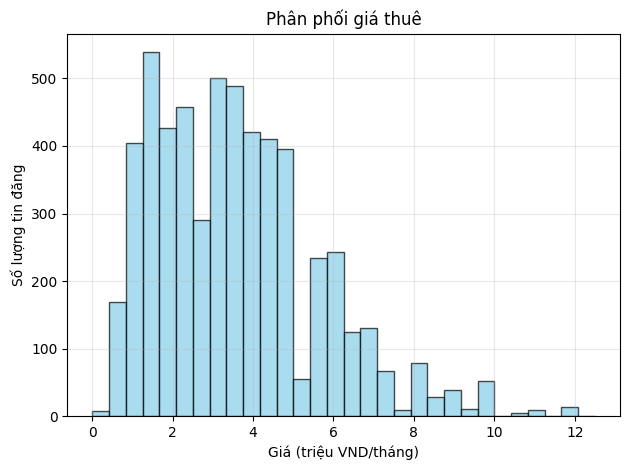

In [50]:
# Phân bố giá thuê
plt.hist(df['price_million'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.xlabel('Giá (triệu VND/tháng)')
plt.ylabel('Số lượng tin đăng')
plt.title('Phân phối giá thuê')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

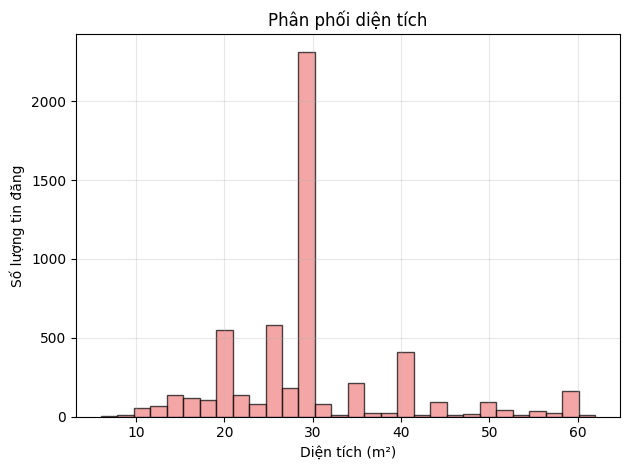

In [51]:
# Phân bố diện tích
plt.hist(df['area_m2'], bins=30, alpha=0.7, color='lightcoral', edgecolor='black')
plt.xlabel('Diện tích (m²)')
plt.ylabel('Số lượng tin đăng')
plt.title('Phân phối diện tích')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Boxplot

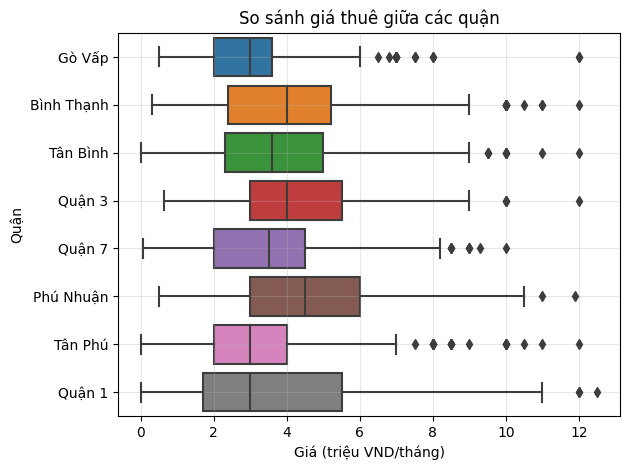

In [52]:
# So sánh giá giữa các quận

top_8_districts = df['district_extracted'].value_counts().head(8).index
filtered_df = df[df['district_extracted'].isin(top_8_districts)]
sns.boxplot(data=filtered_df, y='district_extracted', x='price_million', orient='h')
plt.xlabel('Giá (triệu VND/tháng)')
plt.ylabel('Quận')
plt.title('So sánh giá thuê giữa các quận')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

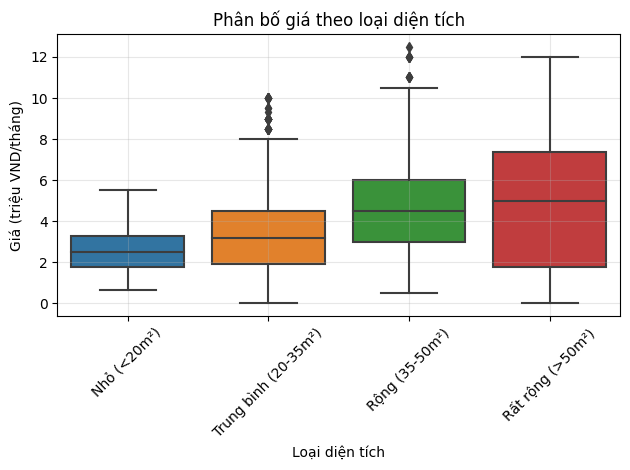

In [53]:
# Giá theo loại diện tích

sns.boxplot(data=df, x='size_category', y='price_million', 
            order=['Nhỏ (<20m²)', 'Trung bình (20-35m²)', 'Rộng (35-50m²)', 'Rất rộng (>50m²)'])
plt.xlabel('Loại diện tích')
plt.ylabel('Giá (triệu VND/tháng)')
plt.title('Phân bố giá theo loại diện tích')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Scatter plot

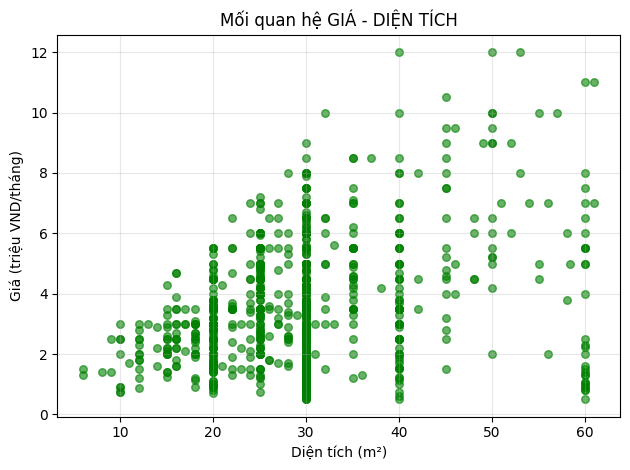

In [54]:
# Mối quan hệ giá – diện tích
# plt.subplot(3, 4, 4)
sample_df = df.sample(min(1000, len(df)), random_state=42)  # Lấy mẫu để biểu đồ rõ hơn
plt.scatter(sample_df['area_m2'], sample_df['price_million'], alpha=0.6, s=30, color='green')
plt.xlabel('Diện tích (m²)')
plt.ylabel('Giá (triệu VND/tháng)')
plt.title('Mối quan hệ GIÁ - DIỆN TÍCH')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

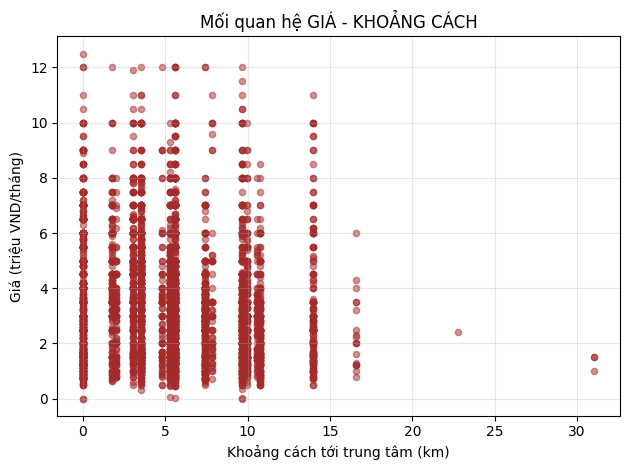

In [55]:
# Giá vs Khoảng cách tới trung tâm
# plt.subplot(3, 4, 11)
plt.scatter(df['distance_to_center_km'], df['price_million'], alpha=0.5, s=20, color='brown')
plt.xlabel('Khoảng cách tới trung tâm (km)')
plt.ylabel('Giá (triệu VND/tháng)')
plt.title('Mối quan hệ GIÁ - KHOẢNG CÁCH')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Heatmap

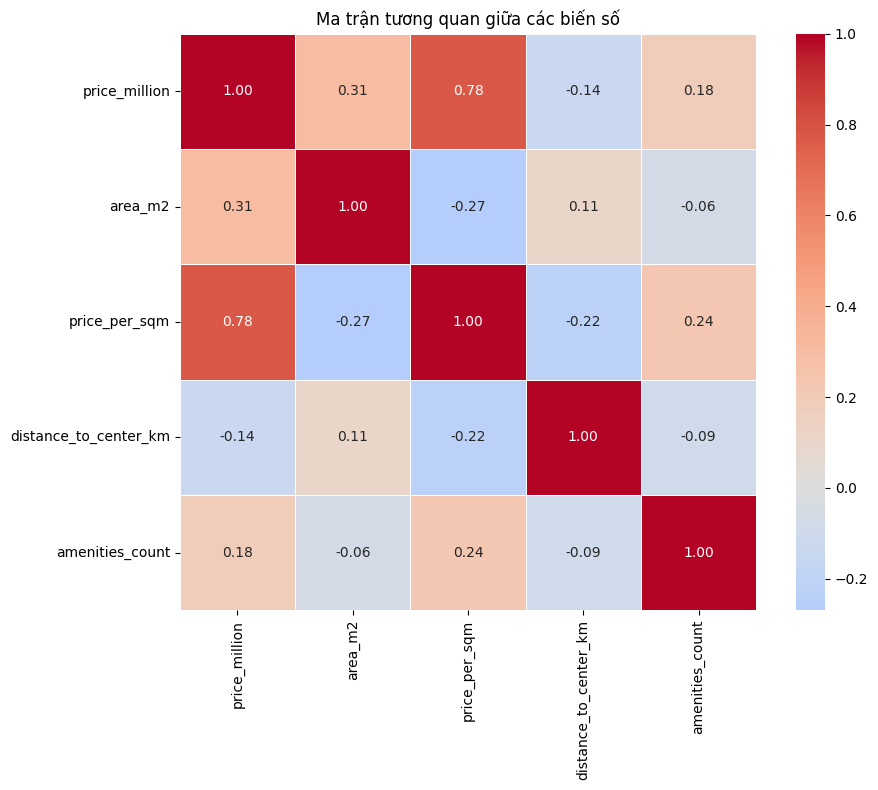

In [56]:
# Ma trận tương quan giữa các biến
numeric_cols = ['price_million', 'area_m2', 'price_per_sqm', 'distance_to_center_km', 'amenities_count']
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f', linewidths=0.5)
plt.title('Ma trận tương quan giữa các biến số')
plt.tight_layout()
plt.show()

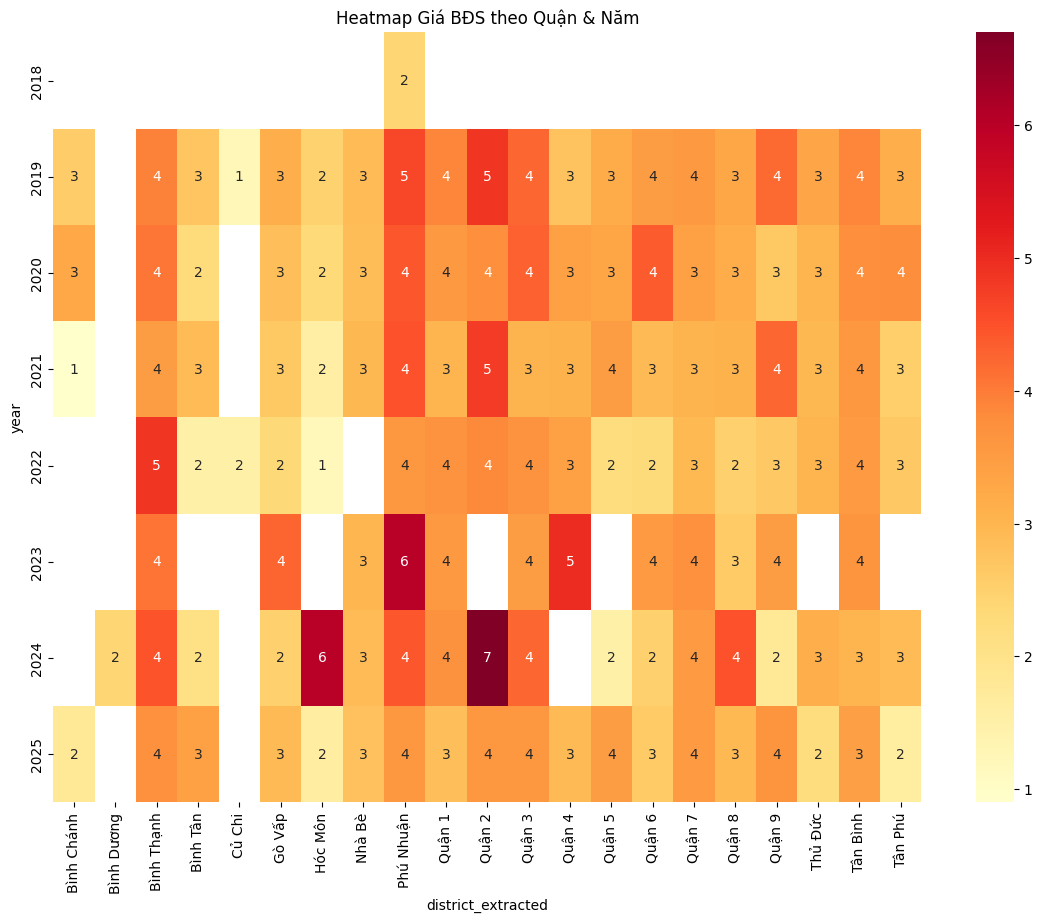

In [57]:
pivot_df = df.groupby(['year', 'district_extracted'])['price_million'].mean().unstack()


plt.figure(figsize=(14, 10))
sns.heatmap(pivot_df, cmap="YlOrRd", annot=True, fmt=".0f")
plt.title("Heatmap Giá BĐS theo Quận & Năm")
plt.show()


## Bar chart

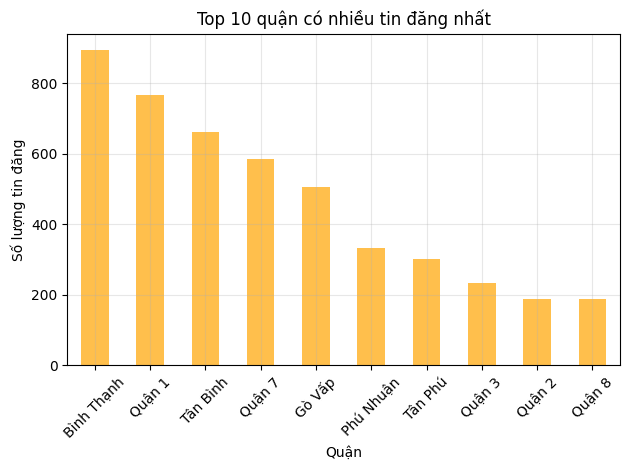

In [58]:
# Số lượng tin đăng theo quận

df['district_extracted'].value_counts().head(10).plot(kind='bar', color='orange', alpha=0.7)
plt.xlabel('Quận')
plt.ylabel('Số lượng tin đăng')
plt.title('Top 10 quận có nhiều tin đăng nhất')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

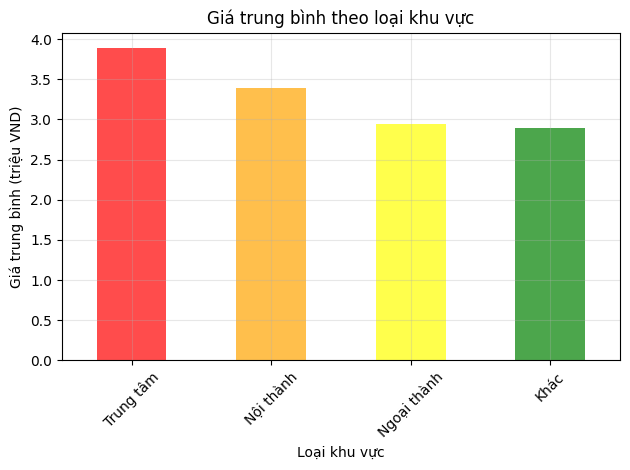

In [59]:
# Giá trung bình theo khu vực

area_price = df.groupby('area_type')['price_million'].mean().sort_values(ascending=False)
area_price.plot(kind='bar', color=['red', 'orange', 'yellow', 'green'], alpha=0.7)
plt.xlabel('Loại khu vực')
plt.ylabel('Giá trung bình (triệu VND)')
plt.title('Giá trung bình theo loại khu vực')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

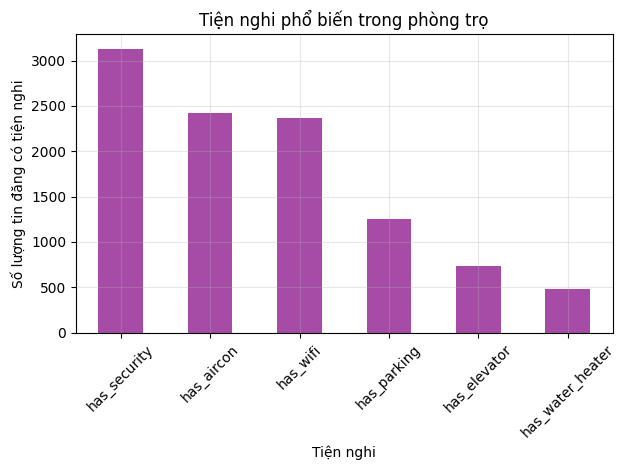

In [60]:
# Tiện nghi phổ biến

amenities_sum = df[['has_wifi', 'has_parking', 'has_aircon', 'has_water_heater', 'has_security', 'has_elevator']].sum()
amenities_sum.sort_values(ascending=False).plot(kind='bar', color='purple', alpha=0.7)
plt.xlabel('Tiện nghi')
plt.ylabel('Số lượng tin đăng có tiện nghi')
plt.title('Tiện nghi phổ biến trong phòng trọ')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

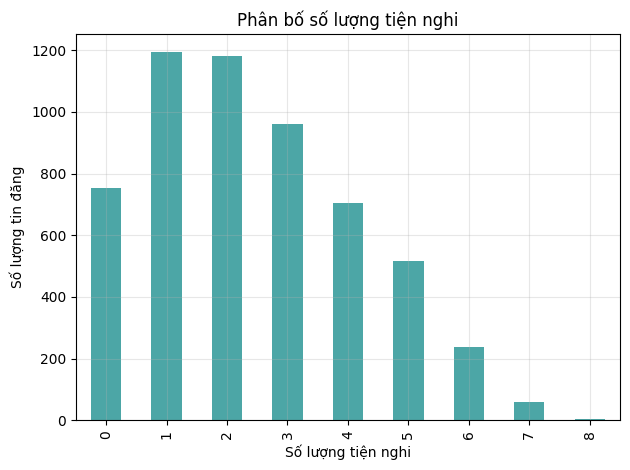

In [61]:
# Số lượng tiện nghi

df['amenities_count'].value_counts().sort_index().plot(kind='bar', color='teal', alpha=0.7)
plt.xlabel('Số lượng tiện nghi')
plt.ylabel('Số lượng tin đăng')
plt.title('Phân bố số lượng tiện nghi')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Pie chart

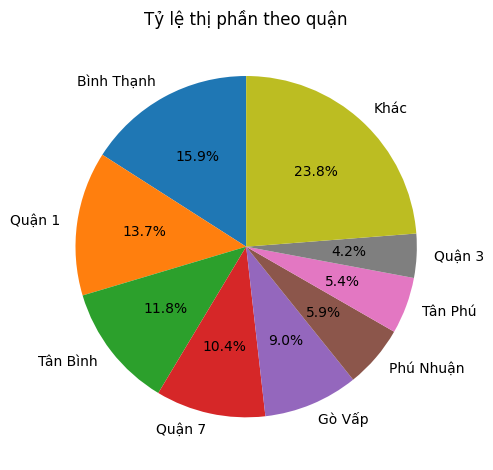

In [62]:
# Tỷ lệ thị phần quận

top_8_pie = df['district_extracted'].value_counts().head(8)
other_count = len(df) - top_8_pie.sum()
pie_data = pd.concat([top_8_pie, pd.Series({'Khác': other_count})])
pie_data.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.ylabel('')
plt.title('Tỷ lệ thị phần theo quận')
plt.tight_layout()
plt.show()

## Plotly Scatter Mapbox

In [63]:
import plotly.express as px

# Tính giá trung bình từng quận theo từng năm
map_df = df.groupby(['year', 'district_extracted', 'lat', 'lng'])['price_million'].mean().reset_index()

fig = px.scatter_mapbox(
    map_df,
    lat="lat",
    lon="lng",
    color="price_million",
    size="price_million",
    animation_frame="year",
    hover_name="district_extracted",
    hover_data={"price_million": True, "lat": False, "lng": False},
    color_continuous_scale="YlOrRd",
    zoom=10,
    height=650
)

fig.update_layout(
    mapbox_style="open-street-map",
    title="Biến động giá phòng theo từng khu vực & thời gian tại TP.HCM",
    margin={"r":0,"t":50,"l":0,"b":0}
)

fig.show()


## Phát hiện insight

In [64]:
# A. Quận có giá thuê cao nhất/thấp nhất

# Top 5 quận giá cao nhất
top_5_expensive = df.groupby('district_extracted')['price_million'].mean().nlargest(5)
print(" TOP 5 QUẬN CÓ GIÁ CAO NHẤT:")
for i, (district, price) in enumerate(top_5_expensive.items(), 1):
    count = len(df[df['district_extracted'] == district])
    print(f"  {i}. {district}: {price:.1f} triệu/tháng ({count} tin)")

# Top 5 quận giá thấp nhất  
top_5_cheap = df.groupby('district_extracted')['price_million'].mean().nsmallest(5)
print("\n TOP 5 QUẬN CÓ GIÁ THẤP NHẤT:")
for i, (district, price) in enumerate(top_5_cheap.items(), 1):
    count = len(df[df['district_extracted'] == district])
    print(f"  {i}. {district}: {price:.1f} triệu/tháng ({count} tin)")

# B. Tương quan giữa diện tích và giá thuê
print("\n B. TƯƠNG QUAN GIỮA DIỆN TÍCH VÀ GIÁ THUÊ")
corr_area_price = df['area_m2'].corr(df['price_million'])
corr_area_price_per_sqm = df['area_m2'].corr(df['price_per_sqm'])

print(f"Tương quan Diện tích - Giá: {corr_area_price:.3f}")
print(f"Tương quan Diện tích - Giá/m²: {corr_area_price_per_sqm:.3f}")

# Phân tích theo nhóm diện tích
print("\n PHÂN TÍCH THEO NHÓM DIỆN TÍCH:")
size_group_analysis = df.groupby('size_category').agg({
    'price_million': ['count', 'mean', 'median'],
    'area_m2': 'mean',
    'price_per_sqm': 'mean'
}).round(2)

display(size_group_analysis)

# C. Mức độ tập trung tin đăng theo khu vực
print("\n C. MỨC ĐỘ TẬP TRUNG TIN ĐĂNG THEO KHU VỰC")

# Phân bố theo khu vực
area_concentration = df['area_type'].value_counts()
print(" PHÂN BỐ TIN ĐĂNG THEO KHU VỰC:")
for area_type, count in area_concentration.items():
    percentage = count / len(df) * 100
    avg_price = df[df['area_type'] == area_type]['price_million'].mean()
    print(f"  {area_type}: {count} tin ({percentage:.1f}%) - Giá TB: {avg_price:.1f} triệu")

# Top quận có nhiều tin đăng nhất
print(f"\n TOP QUẬN CÓ NHIỀU TIN ĐĂNG NHẤT:")
top_districts = df['district_extracted'].value_counts().head(5)
for i, (district, count) in enumerate(top_districts.items(), 1):
    percentage = count / len(df) * 100
    avg_price = df[df['district_extracted'] == district]['price_million'].mean()
    print(f"  {i}. {district}: {count} tin ({percentage:.1f}%) - Giá TB: {avg_price:.1f} triệu")

# D. INSIGHTS QUAN TRỌNG
print("\n D. INSIGHTS QUAN TRỌNG")

# 1. Insight về giá
price_ratio = top_5_expensive.iloc[0] / top_5_cheap.iloc[0]
print(f"1. CHÊNH LỆCH GIÁ: Quận đắt nhất đắt gấp {price_ratio:.1f} lần quận rẻ nhất")

# 2. Insight về mật độ
most_concentrated = top_districts.index[0]
concentration_rate = top_districts.iloc[0] / len(df) * 100
print(f"2. TẬP TRUNG ĐỊA LÝ: {most_concentrated} chiếm {concentration_rate:.1f}% tổng số tin")

# 3. Insight về tương quan
if corr_area_price > 0.5:
    strength = "mạnh"
elif corr_area_price > 0.3:
    strength = "trung bình" 
else:
    strength = "yếu"
print(f"3. TƯƠNG QUAN: Mối quan hệ diện tích - giá có tương quan {strength}")

# 4. Insight về tiện nghi
avg_amenities = df['amenities_count'].mean()
print(f"4. TIỆN NGHI: Trung bình mỗi phòng có {avg_amenities:.1f} tiện nghi")

# 5. Insight về khu vực
most_expensive_area = df.groupby('area_type')['price_million'].mean().idxmax()
print(f"5. KHU VỰC: {most_expensive_area} có giá thuê cao nhất")


 TOP 5 QUẬN CÓ GIÁ CAO NHẤT:
  1. Phú Nhuận: 4.5 triệu/tháng (332 tin)
  2. Quận 2: 4.3 triệu/tháng (187 tin)
  3. Quận 3: 4.2 triệu/tháng (234 tin)
  4. Bình Thạnh: 4.0 triệu/tháng (895 tin)
  5. Tân Bình: 3.8 triệu/tháng (661 tin)

 TOP 5 QUẬN CÓ GIÁ THẤP NHẤT:
  1. Củ Chi: 1.3 triệu/tháng (3 tin)
  2. Bình Dương: 2.4 triệu/tháng (1 tin)
  3. Hóc Môn: 2.4 triệu/tháng (19 tin)
  4. Bình Tân: 2.5 triệu/tháng (184 tin)
  5. Bình Chánh: 2.9 triệu/tháng (45 tin)

 B. TƯƠNG QUAN GIỮA DIỆN TÍCH VÀ GIÁ THUÊ
Tương quan Diện tích - Giá: 0.310
Tương quan Diện tích - Giá/m²: -0.269

 PHÂN TÍCH THEO NHÓM DIỆN TÍCH:


price_million              area_m2 price_per_sqm
                             count  mean median    mean          mean
size_category                                                        
Nhỏ (<20m²)                    499  2.55    2.5   14.79          0.17
Rất rộng (>50m²)               370  5.06    5.0   55.96          0.09
Rộng (35-50m²)                 809  4.76    4.5   39.52          0.12
Trung bình (20-35m²)          3934  3.37    3.2   27.41          0.12


 C. MỨC ĐỘ TẬP TRUNG TIN ĐĂNG THEO KHU VỰC
 PHÂN BỐ TIN ĐĂNG THEO KHU VỰC:
  Trung tâm: 3090 tin (55.1%) - Giá TB: 3.9 triệu
  Nội thành: 1823 tin (32.5%) - Giá TB: 3.4 triệu
  Ngoại thành: 616 tin (11.0%) - Giá TB: 2.9 triệu
  Khác: 83 tin (1.5%) - Giá TB: 2.9 triệu

 TOP QUẬN CÓ NHIỀU TIN ĐĂNG NHẤT:
  1. Bình Thạnh: 895 tin (15.9%) - Giá TB: 4.0 triệu
  2. Quận 1: 767 tin (13.7%) - Giá TB: 3.7 triệu
  3. Tân Bình: 661 tin (11.8%) - Giá TB: 3.8 triệu
  4. Quận 7: 584 tin (10.4%) - Giá TB: 3.5 triệu
  5. Gò Vấp: 504 tin (9.0%) - Giá TB: 3.0 triệu

 D. INSIGHTS QUAN TRỌNG
1. CHÊNH LỆCH GIÁ: Quận đắt nhất đắt gấp 3.4 lần quận rẻ nhất
2. TẬP TRUNG ĐỊA LÝ: Bình Thạnh chiếm 15.9% tổng số tin
3. TƯƠNG QUAN: Mối quan hệ diện tích - giá có tương quan trung bình
4. TIỆN NGHI: Trung bình mỗi phòng có 2.4 tiện nghi
5. KHU VỰC: Trung tâm có giá thuê cao nhất


# PHẦN 5: PHÂN CỤM/ PHÂN NHÓM (CLUSTERING/ CLASSIFICATION - NÂNG CAO)

# PHẦN 6: KẾT LUẬN (CONCLUSIONS & DISCUSSION)

# KẾT THÚC